# TOV Solver for Piece-wise EoS's

## Importing CoRe Data

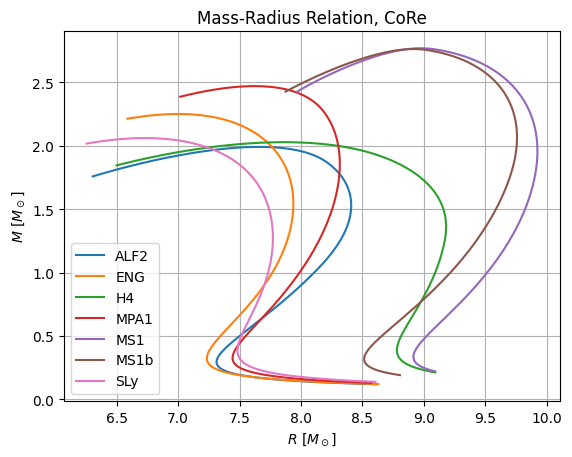

In [2]:
import pandas as pd
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd

# Importing piecewise data

alf = np.loadtxt('alf2_mvsr.dat')
eng = np.loadtxt('eng_mvsr.dat')
h = np.loadtxt('h4_mvsr.dat')
mpa = np.loadtxt('mpa1_mvsr.dat')
ms = np.loadtxt('ms1_mvsr.dat')
msb = np.loadtxt('ms1b_mvsr.dat')
sly = np.loadtxt('sly_mvsr.dat')


afD = pd.DataFrame(alf, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
efD = pd.DataFrame(eng, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
hfD = pd.DataFrame(h, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
mpfD = pd.DataFrame(mpa, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
msfD = pd.DataFrame(ms, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
msbfD = pd.DataFrame(msb, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])
sfD = pd.DataFrame(sly, columns=["rho_c", "R_iso", "M", "Mb", "R", "Lambda", "e_c", "R_inv"])

# mass
dataM_ALF = afD["M"].to_numpy()
dataM_ENG = efD["M"].to_numpy()
dataM_H4 = hfD["M"].to_numpy()
dataM_MPA1 = mpfD["M"].to_numpy()
dataM_MS1 = msfD["M"].to_numpy()
dataM_MS1B = msbfD["M"].to_numpy()
dataM_SLY = sfD["M"].to_numpy()
# radius in Schw.
dataR_ALF = afD["R"].to_numpy()
dataR_ENG = efD["R"].to_numpy()
dataR_H4 = hfD["R"].to_numpy()
dataR_MPA1 = mpfD["R"].to_numpy()
dataR_MS1 = msfD["R"].to_numpy()
dataR_MS1B = msbfD["R"].to_numpy()
dataR_SLY = sfD["R"].to_numpy()
# Love
dataL_ALF = afD["Lambda"].to_numpy()
dataL_ENG = efD["Lambda"].to_numpy()
dataL_H4 = hfD["Lambda"].to_numpy()
dataL_MPA1 = mpfD["Lambda"].to_numpy()
dataL_MS1 = msfD["Lambda"].to_numpy()
dataL_MS1B = msbfD["Lambda"].to_numpy()
dataL_SLY = sfD["Lambda"].to_numpy()

f=plt.figure()
plt.plot(dataR_ALF, dataM_ALF, label=r"ALF2")
plt.plot(dataR_ENG, dataM_ENG, label=r"ENG")
plt.plot(dataR_H4, dataM_H4, label=r"H4")
plt.plot(dataR_MPA1, dataM_MPA1, label=r"MPA1")
plt.plot(dataR_MS1, dataM_MS1, label=r"MS1")
plt.plot(dataR_MS1B, dataM_MS1B, label=r"MS1b")
plt.plot(dataR_SLY, dataM_SLY, label=r"SLy")
plt.xlabel("$R$ [$M_\odot$]")
plt.ylabel("$M$ [$M_\odot$]")
plt.title("Mass-Radius Relation, CoRe")
plt.legend()
plt.grid()
plt.show()

#f.savefig("data_MRcurve.png", bbox_inches='tight', dpi=300)

## Solver

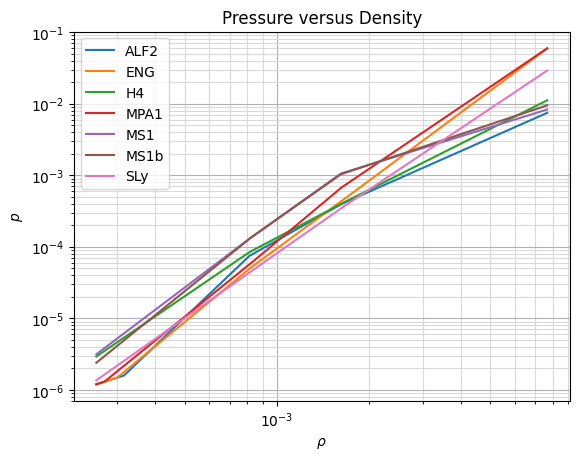

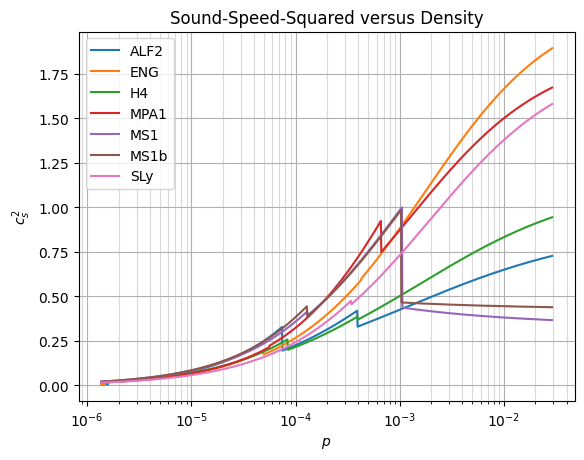

In [3]:
## EoS builder ##
#----------------#
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
import pandas as pd

# Low-density adiabatic index (common for all EoS choices)
gamma0 = 1.3569

def eos_p_polytropic(rho, 
                     K0, K1, K2, K3, 
                     rho0, rho1, rho2, 
                     gamma1, gamma2, gamma3):
    global gamma0
    rho = np.asarray(rho)
    p = np.zeros_like(rho)

    mask1 = (rho>0)&(rho<=rho0)
    mask2 = (rho>rho0)&(rho<=rho1)
    mask3 = (rho>rho1)&(rho<=rho2)
    mask4 = rho>rho2

    p[mask1] = K0*rho[mask1]**gamma0
    p[mask2] = K1*rho[mask2]**gamma1
    p[mask3] = K2*rho[mask3]**gamma2
    p[mask4] = K3*rho[mask4]**gamma3

    return p

def eos_rho_polytropic(p, 
                       K0, K1, K2, K3, 
                       rho0, rho1, rho2,
                       a1, a2, a3,
                       gamma1, gamma2, gamma3):
    global gamma0
    
    p = np.asarray(p)
    rho = np.zeros_like(p)

    p0 = K0 * rho0**gamma0
    p1 = K1 * rho1**gamma1
    p2 = K2 * rho2**gamma2

    mask1 = (p > 0) & (p <= p0)
    mask2 = (p > p0) & (p <= p1)
    mask3 = (p > p1) & (p <= p2)
    mask4 = p > p2

    rho[mask1] = (p[mask1]/K0)**(1/gamma0) + p[mask1]/(gamma0-1)
    rho[mask2] = (1+a1)*(p[mask2]/K1)**(1/gamma1) + p[mask2]/(gamma1-1)
    rho[mask3] = (1+a2)*(p[mask3]/K2)**(1/gamma2) + p[mask3]/(gamma2-1)
    rho[mask4] = (1+a3)*(p[mask4]/K3)**(1/gamma3) + p[mask4]/(gamma3-1)

    return rho

def eos_cs2_polytropic(p,
                  K0, K1, K2, K3, 
                  rho0, rho1, rho2,
                  a1, a2, a3,
                  gamma1, gamma2, gamma3):
    global gamma0

    p = np.asarray(p)
    cs2 = np.zeros_like(p)

    p0 = K0 * rho0**gamma0
    p1 = K1 * rho1**gamma1
    p2 = K2 * rho2**gamma2

    mask1 = (p > 0) & (p <= p0)
    mask2 = (p > p0) & (p <= p1)
    mask3 = (p > p1) & (p <= p2)
    mask4 = p > p2

    rho0 = (p[mask1]/K0)**(1/gamma0) + p[mask1]/(gamma0-1)
    rho1 = (1+a1)*(p[mask2]/K1)**(1/gamma1) + p[mask2]/(gamma1-1)
    rho2 = (1+a2)*(p[mask3]/K2)**(1/gamma2) + p[mask3]/(gamma2-1)
    rho3 = (1+a3)*(p[mask4]/K3)**(1/gamma3) + p[mask4]/(gamma3-1)

    cs2[mask1] = gamma0*p[mask1]/(rho0+p[mask1])
    cs2[mask2] = gamma1*p[mask2]/(rho1+p[mask2])
    cs2[mask3] = gamma2*p[mask3]/(rho2+p[mask3])
    cs2[mask4] = gamma3*p[mask4]/(rho3+p[mask4])

    return cs2
        
polytropes = {
    'ALF2': {
        'K0': 8.9493e-02, 
        'K1': 2.8241e+08,
        'K2': 2.1056e+03, 
        'K3': 7.4029e+01,
        'rho0': 3.1534e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.2471e-02, 
        'a2': -2.2648e-02, 
        'a3': -1.2348e-01,
        'gamma1': 4.070,
        'gamma2': 2.411,
        'gamma3': 1.890,
    },
    'ENG': {
        'K0': 8.9493e-02,
        'K1': 3.5764e+06,
        'K2': 2.3260e+05, 
        'K3': 2.9693e+05,
        'rho0': 2.9919e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.1883e-02,
        'a2': 7.5282e-03,
        'a3': 9.7044e-03,
        'gamma1': 3.514,
        'gamma2': 3.130,
        'gamma3': 3.168,
    },
    'H4': {
        'K0': 8.9493e-02, 
        'K1': 8.2329e+04,
        'K2': 7.3519e+02, 
        'K3': 3.8172e+02,
        'rho0': 1.4374e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 8.6673e-03,
        'a2': -2.0209e-02,
        'a3': -3.7741e-02,
        'gamma1': 2.909,
        'gamma2': 2.246,
        'gamma3': 2.144,
    },
    'MPA1': {
        'K0': 8.9493e-02, 
        'K1': 2.5193e+06,
        'K2': 6.1760e+06, 
        'K3': 7.5693e+04,
        'rho0': 2.7170e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.1428e-02, 
        'a2':1.2818e-02,
        'a3': -4.5072e-02,
        'gamma1': 3.446,
        'gamma2': 3.572,
        'gamma3': 2.887,
    },
    'MS1': {
        'K0': 8.9493e-02, 
        'K1': 1.1971e+06,
        'K2': 3.0747e+05, 
        'K3': 5.2631e+00,
        'rho0': 1.5246e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 9.1399e-03,
        'a2': 2.3772e-03,
        'a3': -1.6831e+00,
        'gamma1': 3.224,
        'gamma2': 3.033,
        'gamma3': 1.325,
    },
    'MS1b': {
        'K0': 8.9493e-02, 
        'K1': 6.1970e+06,
        'K2': 2.6110e+05, 
        'K3': 9.7885e+00,
        'rho0': 1.8401e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 9.9510e-03,
        'a2': -4.3735e-03,
        'a3': -1.1879e+00,
        'gamma1': 3.456,
        'gamma2': 3.011,
        'gamma3': 1.425,
    },
    'SLy': {
        'K0': 8.9493e-02, 
        'K1': 8.4581e+04,
        'K2': 7.4943e+04, 
        'K3': 3.1074e+04,
        'rho0': 2.3674e-04,
        'rho1': 8.1147e-04,
        'rho2': 1.6191e-03,
        'a1': 1.0471e-02,
        'a2': 1.0242e-02,
        'a3': 2.3410e-03,
        'gamma1': 3.005,
        'gamma2': 2.988,
        'gamma3': 2.851
    },
    # ...
}

# Create an EOS function that uses the parameters
def make_polytrope_eos_p_and_rho(name):
    params = polytropes[name]
    kaps = [params['K0'], params['K1'], params['K2'], params['K3']]
    rhos = [params['rho0'], params['rho1'], params['rho2']]
    a_s = [params['a1'], params['a2'], params['a3']]
    gammas = [params['gamma1'], params['gamma2'], params['gamma3']] #params['gamma0'],
    return (
        lambda rho: eos_p_polytropic(rho, *kaps, *rhos, *gammas),
        lambda p: eos_rho_polytropic(p, *kaps, *rhos, *a_s, *gammas),
    )

def make_polytrope_eos_p_and_cs2(name):
    params = polytropes[name]
    kaps = [params['K0'], params['K1'], params['K2'], params['K3']]
    rhos = [params['rho0'], params['rho1'], params['rho2']]
    a_s = [params['a1'], params['a2'], params['a3']]
    gammas = [params['gamma1'], params['gamma2'], params['gamma3']] #params['gamma0'], 
    return (
        lambda rho: eos_p_polytropic(rho, *kaps, *rhos, *gammas),
        lambda p: eos_cs2_polytropic(p, *kaps, *rhos, *a_s, *gammas),
    )

# Make a list of all EOS that we want to test
eos_list_p_and_rho = [
    #("POLYn1: $K={:.0f}".format(K1) + r"$, $\Gamma=" + "{:.0f}".format(Gamma1)+ r"$", eos_p_POLYn1, eos_rho_POLYn1)]+[
    (name,) + make_polytrope_eos_p_and_rho(name) for name in polytropes ]

eos_list_p_and_cs2 = [
    #("POLYn1: $K={:.0f}".format(K1) + r"$, $\Gamma=" + "{:.0f}".format(Gamma1)+ r"$", eos_p_POLYn1, eos_rho_POLYn1)]+[
    (name,) + make_polytrope_eos_p_and_cs2(name) for name in polytropes ]

# Plot all EOS
 
rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 6 * rho_base
rho_c_space = np.logspace(np.log10(rho_min),np.log10(rho_max), 1000)

f1=plt.figure()
for name, eos_p, _ in eos_list_p_and_rho:
    params = polytropes[name]
    plt.loglog(rho_c_space, eos_p(rho_c_space), label=name)

plt.title("Pressure versus Density")
plt.xlabel(r"$\rho$ ")
plt.ylabel(r"$p$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

# Plot all EOS
f2=plt.figure()
for name, _, eos_cs2 in eos_list_p_and_cs2:
    params = polytropes[name]
    p_space = eos_p(rho_c_space)
    plt.semilogx(p_space, eos_cs2(p_space), label=name)

plt.title("Sound-Speed-Squared versus Density")
plt.xlabel(r"$p$ ")
plt.ylabel(r"$c_s^2$")
plt.grid()
plt.grid(which="minor", color="0.85")
plt.legend();

#f2.savefig("all_eos_cs2vrho.png", bbox_inches='tight', dpi=300)

In [4]:
## The TOV Solver (with Tidal ODE) ##
#-----------------------------------#
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
from astropy import units, constants as const
from scipy.integrate import ode
from scipy.integrate import solve_ivp
import pandas as pd

#TOV equations (Schwarzschild Coord.s!!)

def dp_dr(r, p, m, rho):
    if r <= 0:
        return 0
    return -(rho + p) * (m + 4 * pi * r**3 * p) / r / (r - 2 * m) # 2*m indicates that the coordinates are Schwarzschild
    
def dm_dr(r, p, m, rho):
    return 4 * pi * r**2 * rho

def dy2_dr(r, y, p, m, rho, cs2):
    if r<=1e-10:
        return 2
    cs2 = np.clip(cs2, 1e-12, 1.0)
    F = 1/r + (2*m/r**2 + 4*pi*r*(p-rho))/(1 - 2*m/r)
    G = (-2*(2+1)/r**2 + 4*pi*((p+rho)/(cs2) + 5*rho + 9*p) - (4*pi*r*p + m/r**2)**2/(1-2*m/r))/(1 - 2*m/r)
    return -(y**2/r + y*F + r*G)
    
def tov_equations(r, state, eos_rho, eos_cs2):
    p, m, y = state
    rho = eos_rho(p)
    cs2 = eos_cs2(p)
    return [
        dp_dr(r, p, m, rho),
        dm_dr(r, p, m, rho),
        dy2_dr(r, y, p, m, rho, cs2)
    ]
    
#TOV integrator, from r=0 outwards, until p=0 (we yield r=R)

def solve_tov_equations(p_central, eos_rho, eos_cs2, step):
    r_initial = 1e-10
    state_initial = [ p_central, 0., 2 ]
    
    integrator = ode(tov_equations).set_integrator('LSODA', rtol=1e-8, atol=1e-10, nsteps=10000, max_step=1e4)
    integrator.set_initial_value(state_initial, r_initial)
    integrator.set_f_params(eos_rho, eos_cs2)
    
    r_path = []
    p_path = []
    m_path = []
    y_path = []

    while integrator.successful():
        integrator.integrate(integrator.t + step)

        r = integrator.t
        p, m, y = integrator.y

        r_path.append(r)
        p_path.append(p)
        m_path.append(m)
        y_path.append(y)

        if p < 0:
            break
    return (np.array(r_path),
            np.array(p_path),
            np.array(m_path),
            np.array(y_path)
        )
    

## MRL Data Compiler

In [13]:
# This may take a few minutes

rho_base = 1.28e-3
rho_min = 1/5 * rho_base
rho_max = 8 * rho_base

def all_eos_MRL(eos_p,
                   eos_rho,
                   eos_cs2,
                   rho_central_start=rho_min,
                   rho_central_log_step=0.05,
                   rho_central_stop=rho_max,
                   stop_at_maximum_mass=False):

    data = pd.DataFrame(columns=['rho_central', 'M', 'R', 'Lambda2']).set_index('rho_central')
    rho_central = rho_central_start
    while rho_central < rho_central_stop:
        # Central pressure
        p_central = eos_p(rho_central)
        # Solve TOV + tidal
        r, p, m, y = solve_tov_equations(
            p_central=p_central,
            eos_rho=eos_rho,
            eos_cs2=eos_cs2,
            step=0.01)

        R = r[-1]
        M = m[-1]
        Y2 = y[-1]   

        # --- Compute compactness ---
        C = M / R

        if C < 1e-10:
            k2 = np.nan
        else:
            log = np.log(1 - 2*C)

            k2=((8 * C**5 / 5) * (1 - 2*C)**2 * (2 + 2*C*(Y2 - 1) - Y2))/((2*C*(6 - 3*Y2 + 3*C*(5*Y2 - 8)) +
        4*C**3*(13 - 11*Y2 + C*(3*Y2 - 2) + 2*C**2*(1 + Y2)) +
        3*(1 - 2*C)**2 * (2 - Y2 + 2*C*(Y2 - 1)) * log))

        if np.isfinite(k2) and k2 > 0:
                Lambda2 = (2/3) * k2 / C**5
        else:
                Lambda2 = np.nan
                
        # Optional stopping at maximum mass
        if stop_at_maximum_mass and len(data) > 0:
            if M < data['M'].iat[-1]:
                break

        data.loc[rho_central] = [M, R, Lambda2]

        # Log stepping
        rho_central += rho_central * rho_central_log_step
    return data

all_eos_data = dict([
    (eos_name, all_eos_MRL(
        eos_p, eos_rho, eos_cs2,
        stop_at_maximum_mass=True))
    for eos_name, eos_p, eos_rho in eos_list_p_and_rho
])

## CoRe vs. Solver

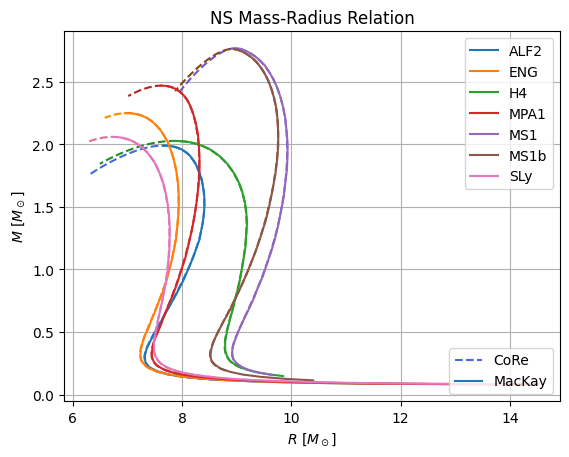

In [14]:
f = plt.figure() 
plt.plot(dataR_ALF, dataM_ALF, ls='--', color='royalblue')
plt.plot(dataR_ENG, dataM_ENG, ls='--', color='darkorange')
plt.plot(dataR_H4, dataM_H4, ls='--', color='forestgreen')
plt.plot(dataR_MPA1, dataM_MPA1, ls='--', color='firebrick')
plt.plot(dataR_MS1, dataM_MS1, ls='--', color='slateblue')
plt.plot(dataR_MS1B, dataM_MS1B, ls='--', color='saddlebrown')
plt.plot(dataR_SLY, dataM_SLY, ls='--', color='palevioletred')
#
for eos_name, MRL_data in all_eos_data.items():
    plt.plot(MRL_data['R'], MRL_data['M'], label=eos_name, ls='-')
#
colors = ['b', 'r', 'g', 'c']
parameters = [1,2,3,4]
for p in parameters:

  color = colors[parameters.index(p)]

lines = plt.gca().get_lines()
include = [0,7]
legend2 = plt.legend([lines[i] for i in include],['CoRe','MacKay'], loc=4)
plt.gca().add_artist(legend2)
#
plt.xlabel("$R$ [$M_\odot$]")
plt.ylabel("$M$ [$M_\odot$]")
plt.title("NS Mass-Radius Relation")
plt.grid()
plt.legend();

#f.savefig("all_eos_MRcurve.png", bbox_inches='tight', dpi=300)

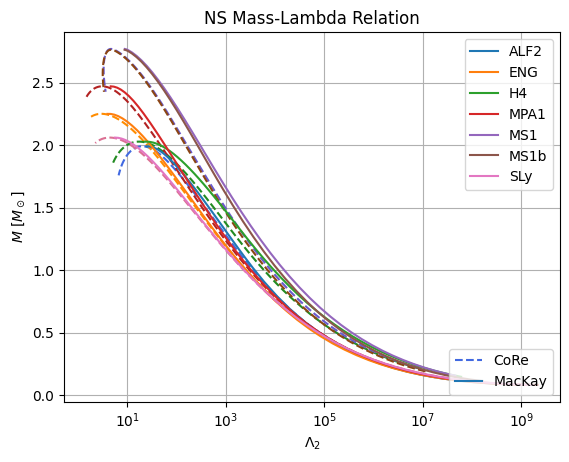

In [15]:
f = plt.figure() 
plt.semilogx(dataL_ALF, dataM_ALF, ls='--', color='royalblue')
plt.semilogx(dataL_ENG, dataM_ENG, ls='--', color='darkorange')
plt.semilogx(dataL_H4, dataM_H4, ls='--', color='forestgreen')
plt.semilogx(dataL_MPA1, dataM_MPA1, ls='--', color='firebrick')
plt.semilogx(dataL_MS1, dataM_MS1, ls='--', color='slateblue')
plt.semilogx(dataL_MS1B, dataM_MS1B, ls='--', color='saddlebrown')
plt.semilogx(dataL_SLY, dataM_SLY, ls='--', color='palevioletred')
#
for eos_name, MRL_data in all_eos_data.items():
    plt.plot(MRL_data['Lambda2'], MRL_data['M'], label=eos_name, ls='-')
#
colors = ['b', 'r', 'g', 'c']
parameters = [1,2,3,4]
for p in parameters:

  color = colors[parameters.index(p)]

lines = plt.gca().get_lines()
include = [0,7]
legend2 = plt.legend([lines[i] for i in include],['CoRe','MacKay'], loc=4)
plt.gca().add_artist(legend2)
#
plt.xlabel("$\Lambda_2$")
plt.ylabel("$M$ [$M_\odot$]")
plt.title("NS Mass-Lambda Relation")
plt.grid()
plt.legend();

#f.savefig("all_eos_MRcurve.png", bbox_inches='tight', dpi=300)

## Making .dat Files for each EoS

In [28]:
#Turning extrapolated data into .dat files

#for eos_name, df in all_eos_data.items():
#    filename = f"{eos_name}_MacKay.dat"
#    
#    df.to_csv(
#        filename,
#        sep=' ',          # space-separated (standard in physics)
#        index=True,       # keeps rho_central
#        header=True
#    )